# Preprocessing & Exploratory Data Analysis (EDA)
## Dataset: Employee Burnout Level Prediction

---

1. **Data Preprocessing**: membersihkan dan menyiapkan data mentah agar layak digunakan model.
2. **Exploratory Data Analysis (EDA)**: memahami karakteristik, distribusi, dan pola data melalui statistik deskriptif dan visualisasi.

**Tentang Dataset:**  
Dataset berisi observasi **7.000 karyawan** dengan atribut pekerjaan dan gaya hidup. Target prediksi adalah `burnout_level` (Low / Medium / High).

| Fitur | Tipe | Deskripsi |
|-------|------|-----------|
| `age` | Numerik | Usia karyawan (tahun) |
| `experience_years` | Numerik | Lama pengalaman kerja |
| `daily_work_hours` | Numerik | Jam kerja per hari |
| `sleep_hours` | Numerik | Jam tidur per hari |
| `caffeine_intake` | Numerik | Konsumsi kafein per hari |
| `bugs_per_day` | Numerik | Jumlah bug yang dikerjakan per hari |
| `commits_per_day` | Numerik | Jumlah commit per hari |
| `meetings_per_day` | Numerik | Jumlah meeting per hari |
| `screen_time` | Numerik | Waktu di depan layar (jam) |
| `exercise_hours` | Numerik | Durasi olahraga (jam) |
| `stress_level` | Numerik | Tingkat stres (skala 0–100) |
| `burnout_level` | Kategorik | **Target**: Low / Medium / High |

## 1. Import Library

Library yang digunakan:
- **pandas & numpy** untuk manipulasi dan komputasi data tabular
- **matplotlib & seaborn** untuk visualisasi statistik

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. Load Dataset

Kita load dataset dan lakukan inspeksi awal untuk memahami struktur data (`shape`, tipe kolom, dan sampel baris pertama).

In [14]:
df = pd.read_csv('dataset.csv')
print(f"Shape dataset: {df.shape[0]:,} baris x {df.shape[1]} kolom")
df.head()

Shape dataset: 7,000 baris x 12 kolom


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.00,12.00,10.33,4.45,2.00,11.00,4.00,1.00,15.07,0.14,55.96,Medium
1,39.00,10.00,8.62,5.77,5.00,15.00,11.00,5.00,13.25,0.54,82.22,High
2,34.00,13.00,NaN,4.03,5.00,2.00,18.00,9.00,11.18,1.54,61.77,Medium
3,30.00,1.00,6.85,6.47,2.00,15.00,26.00,1.00,11.14,0.96,54.98,Medium
4,27.00,7.00,4.24,5.80,NaN,9.00,17.00,7.00,8.05,0.36,27.90,Low


## 3. Pemahaman lebih dalam mengenai Dataset

Tahap ini bertujuan untuk:
- Mengetahui tipe data tiap kolom
- Melihat statistik seperti mean, std, min, max, kuartil
- Mengidentifikasi potensi masalah data di awal agar tidak merusak proses berikutnya

Statistik deskriptif penting sebelum preprocessing karena nilai mean, std, dan range akan menentukan strategi normalisasi atau imputasi yang sesuai.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   object 
dtypes: float64(11), object(1)
memory usage: 656.4+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,6860.00,32.13,7.23,20.00,26.00,32.00,38.00,44.00
experience_years,6860.00,9.58,5.76,0.00,5.00,10.00,15.00,19.00
daily_work_hours,6860.00,9.00,2.86,4.00,6.56,8.99,11.42,14.00
sleep_hours,6860.00,6.49,1.45,4.00,5.22,6.46,7.74,9.00
caffeine_intake,6860.00,3.54,2.28,0.00,2.00,4.00,6.00,7.00
bugs_per_day,6860.00,9.48,5.75,0.00,5.00,9.00,14.00,19.00
commits_per_day,6860.00,14.46,8.67,0.00,7.00,14.00,22.00,29.00
meetings_per_day,6860.00,4.55,2.86,0.00,2.00,5.00,7.00,9.00
screen_time,6860.00,11.97,3.09,5.21,9.46,12.02,14.42,18.93
exercise_hours,6860.00,1.01,0.58,0.00,0.51,1.02,1.51,2.00


## 4. Penanganan Missing Values


Strategi penanganan:

| Kondisi | Strategi |
|---------|----------|
| < 5% baris missing | Drop baris |
| > 5%, fitur numerik | Imputasi mean/median |
| > 5%, fitur kategorik | Imputasi modus |
| Banyak missing dan fitur tidak penting | Drop kolom |

Kita periksa dulu pola missing valuesnya apakah berada di baris yang sama atau tersebar acak.

**sumber**: https://medium.com/@jannatulnawrin/data-preprocessing-strategies-to-deal-with-missing-values-326b86429de8

In [18]:
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)
missing_df    = pd.DataFrame({'Missing Count': missing_count,'Missing (%)':   missing_pct})
print(missing_df.to_string())

                  Missing Count  Missing (%)
age                         140         2.00
experience_years            140         2.00
daily_work_hours            140         2.00
sleep_hours                 140         2.00
caffeine_intake             140         2.00
bugs_per_day                140         2.00
commits_per_day             140         2.00
meetings_per_day            140         2.00
screen_time                 140         2.00
exercise_hours              140         2.00
stress_level                140         2.00
burnout_level               140         2.00


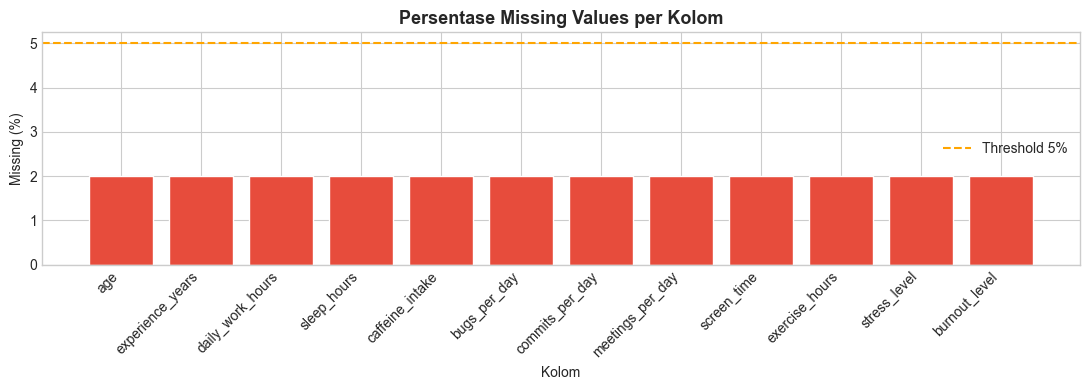

In [19]:
# Visualisasi missing values per kolom
fig, ax = plt.subplots(figsize=(11, 4))
missing_pct_all = (df.isnull().sum() / len(df) * 100)
bar_colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in missing_pct_all.values]
bars = ax.bar(missing_pct_all.index, missing_pct_all.values, color=bar_colors, edgecolor='white')
ax.axhline(y=5, color='orange', linestyle='--', linewidth=1.5, label='Threshold 5%')
ax.set_title('Persentase Missing Values per Kolom', fontsize=13, fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.set_xlabel('Kolom')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
# Cek apakah baris yang missing SAMA untuk semua kolom
missing_rows = df[df.isnull().any(axis=1)]
all_same = missing_rows.isnull().all(axis=1).all()
print(f"Semua kolom missing di baris yang sama: {all_same}")
print(f"Persentase missing: {len(missing_rows)/len(df)*100:.2f}% ({len(missing_rows)} baris)")

Semua kolom missing di baris yang sama: False
Persentase missing: 21.57% (1510 baris)


karena tidak semua missing values nya di baris yang sama dan jumlahnya sangat besar yakni 21.57% dari total dataset. lalu kami juga tidak ingin kehilangan 1570 baris data. Selanjutnya kami melakukan pengecekan data duplikat sebelum melakukan visualisasi untuk menentukan teknik imputasi yang akan dipakai.

## 5. Pengecekan Data Duplikat

Data duplikat dapat menyebabkan model *overfitting* karena baris yang sama dihitung lebih dari sekali selama training. Kita pastikan tidak ada duplikat setelah proses imputasi.

In [17]:
n_dup = df_clean.duplicated().sum()
print(f"Jumlah baris duplikat: {n_dup}")
if n_dup == 0:
    print("Tidak ada duplikat")

Jumlah baris duplikat: 0
Tidak ada duplikat


Setelah kami melakukan pengecekan terhadap baris duplikat ternyata kami tidak menemukan adanya baris yang duplikat.

## 7. Distribusi Fitur Numerik

Memahami distribusi tiap fitur berguna untuk:
- Mendeteksi **skewness** (kemiringan distribusi)
- Menentukan apakah data perlu **transformasi** (log, sqrt) sebelum modeling
- Mengetahui apakah distribusi mendekati **normal** (penting untuk algoritma seperti Naive Bayes Gaussian dan LDA)

Pada histogram, garis **merah** = mean, garis **biru** = median. Jika keduanya berdekatan, distribusi cenderung simetris.

Ringkasan Skewness & Kurtosis:
                  Skewness  Kurtosis Distribusi
age                  -0.03     -1.21   Simetris
experience_years     -0.03     -1.21   Simetris
daily_work_hours      0.01     -1.18   Simetris
sleep_hours           0.03     -1.21   Simetris
caffeine_intake      -0.03     -1.24   Simetris
bugs_per_day          0.02     -1.20   Simetris
commits_per_day      -0.00     -1.22   Simetris
meetings_per_day     -0.02     -1.21   Simetris
screen_time          -0.01     -0.90   Simetris
exercise_hours       -0.03     -1.19   Simetris
stress_level         -0.06     -0.60   Simetris


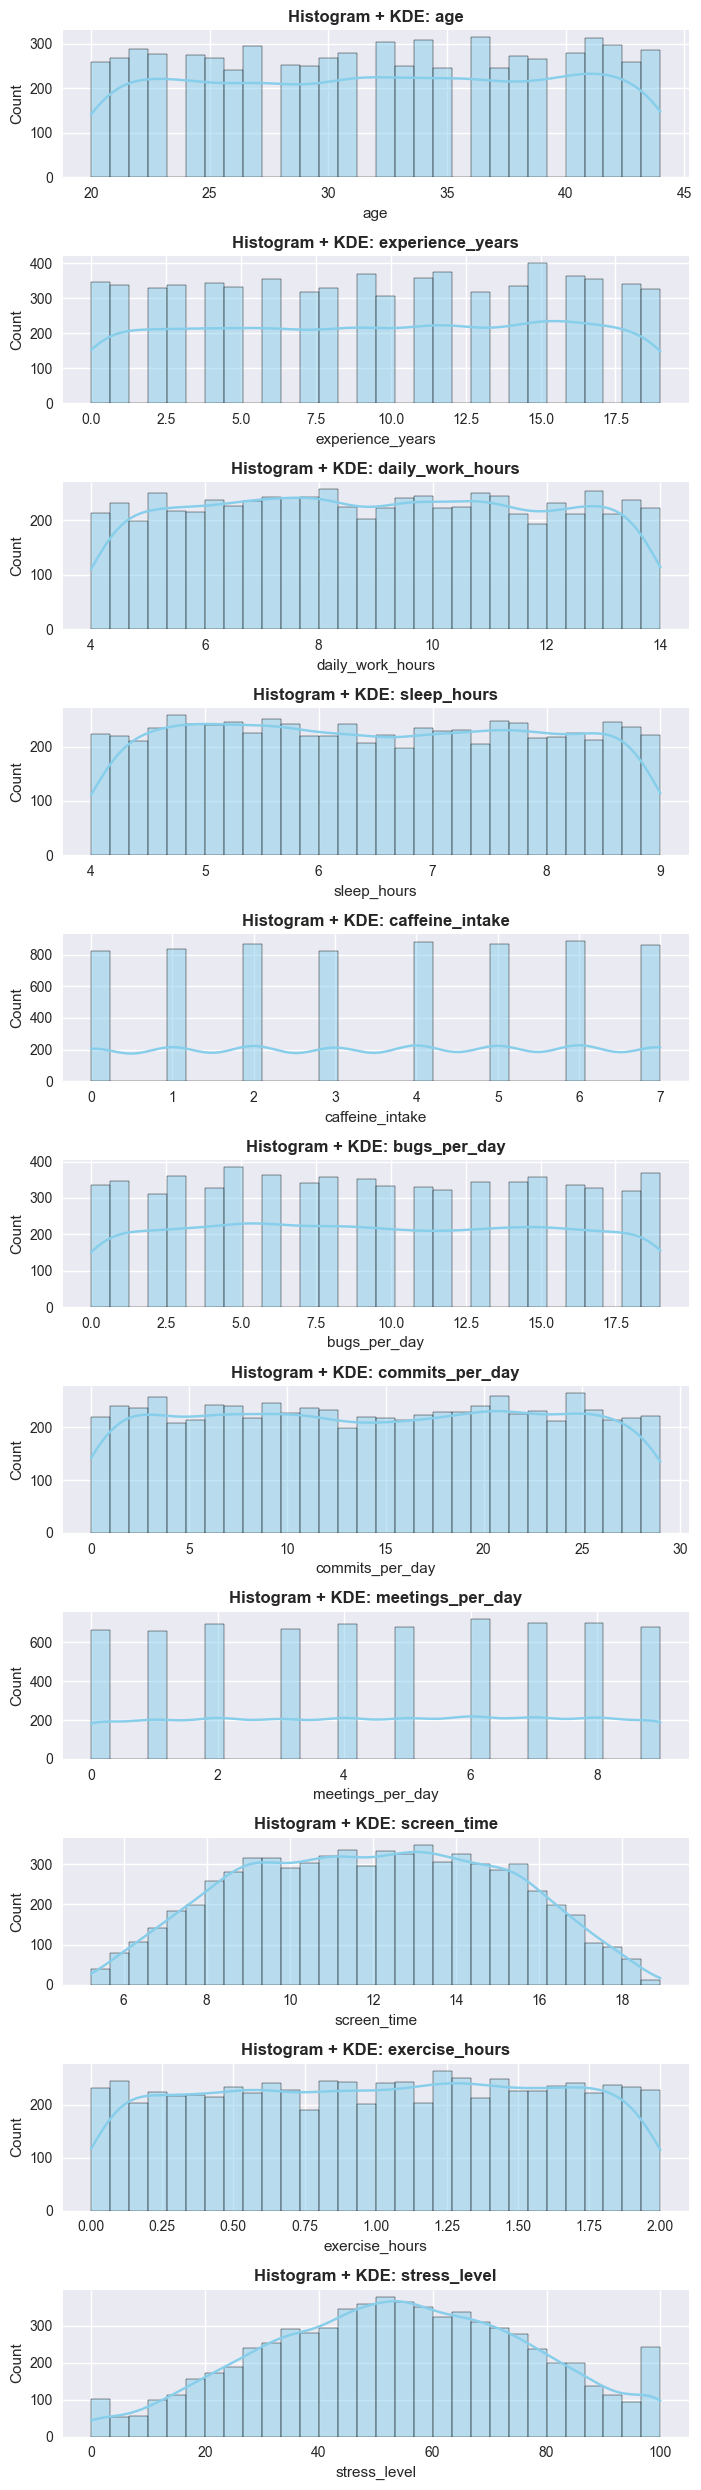

In [ ]:
# Ringkasan skewness dan kurtosis
num_cols = df.select_dtypes(include=np.number).columns.tolist()
skewness = df[num_cols].skew().round(3)
kurtosis = df[num_cols].kurt().round(3)
summary  = pd.DataFrame({'Skewness': skewness, 'Kurtosis': kurtosis})
summary['Distribusi'] = summary['Skewness'].apply(
    lambda x: 'Simetris' if abs(x) < 0.5 else ('Right-skewed' if x > 0 else 'Left-skewed')
)
print("Ringkasan Skewness & Kurtosis:")
print(summary.to_string())
plt.style.use('seaborn-v0_8')
sns.set_palette("muted")
plt.rcParams['figure.figsize'] = (14, 10)


fig = plt.figure(figsize=(20, 25))

for i, col in enumerate(num_cols, 1):
    # Histogram + KDE
    plt.subplot(len(num_cols), 3, 3*(i-1) + 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Histogram + KDE: {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

---
### Insight dari Distribusi Fitur Numerik

**Pertanyaan yang kami ajukan bagaimana bentuk distribusi fitur-fitur ini akan mempengaruhi data imputation dan model?

**Temuan:**
- Sebagian besar fitur memiliki skewness < 0.5 sehingga distribusi nya cukup simetris
- `meetings_per_day` dan `caffeine_intake` terlihat lebih flat/uniform (data merata tanpa puncak jelas)
- `stress_level` mendekati distribusi normal

**Interpretasi:**

Kami terkejut karena distribusi data di dataset ini sangat bagus bahkan mendekati simetris. Tidak ada fitur yang memerlukan transformasi distribusi. Fitur-fitur ini sudah oke banget untuk tree-based models. Untuk model berbasis jarak/gradient, nanti akan kami tambahkan StandardScaler saat modeling.

## 8. Deteksi Outlier

**Outlier** adalah observasi yang nilainya jauh menyimpang dari distribusi mayoritas. Outlier dapat mengganggu model berbasis jarak (KNN, SVM, Regresi Logistik), namun model berbasis tree (Decision Tree, Random Forest) relatif robust terhadap outlier.

Metode deteksi: **IQR Method**

$$\text{Lower bound} = Q1 - 1.5 \times IQR$$
$$\text{Upper bound} = Q3 + 1.5 \times IQR$$

Nilai di luar range tersebut dikategorikan sebagai outlier.

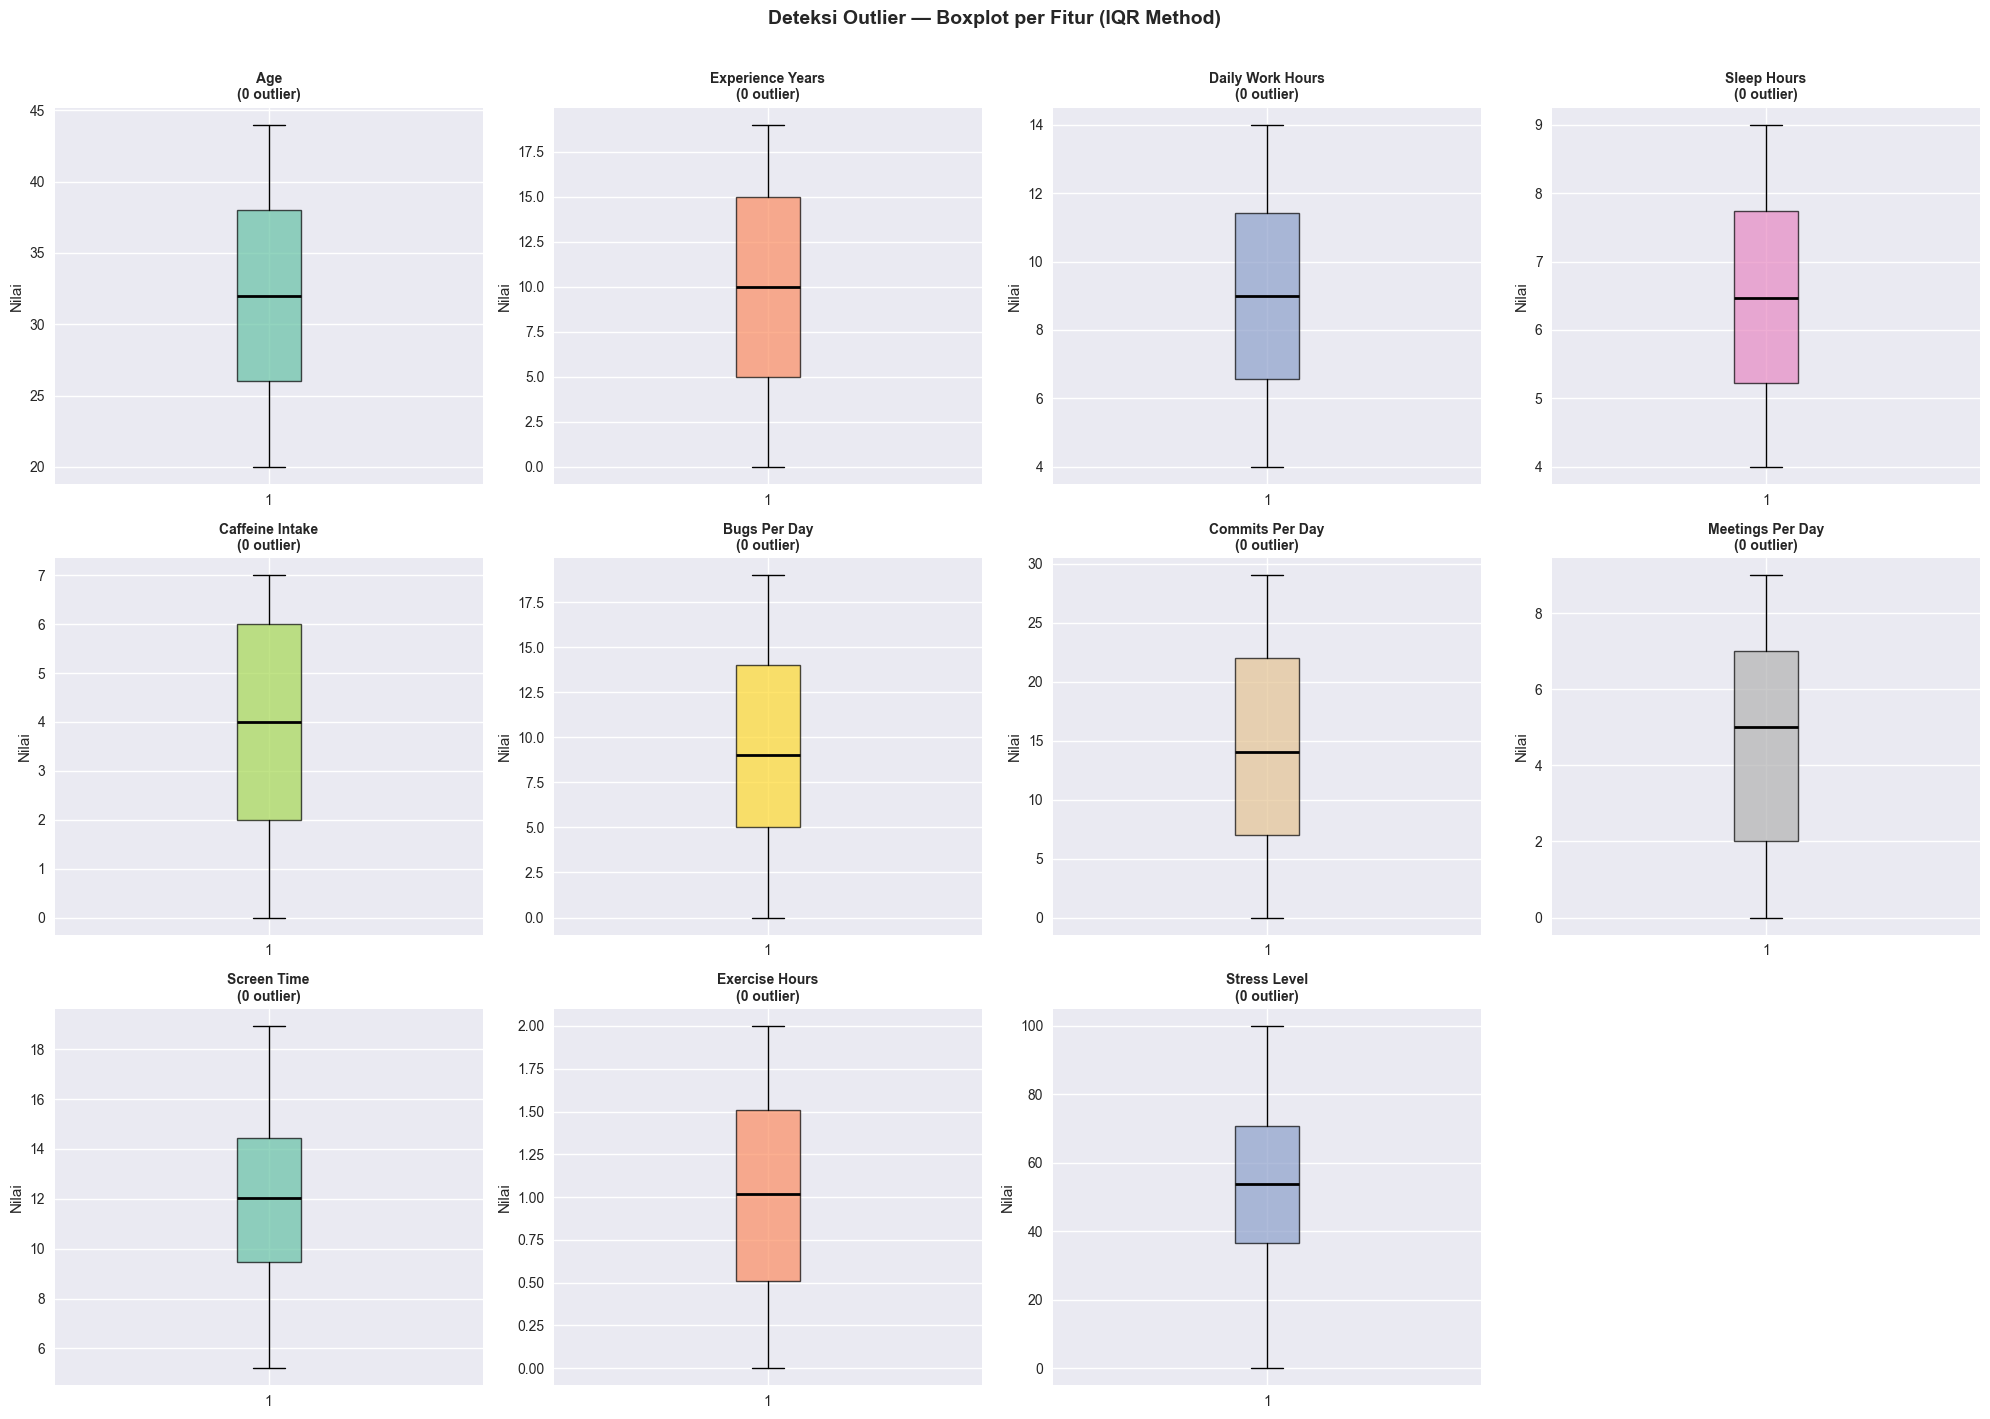

Ringkasan Outlier:
                    Q1    Q3   IQR  N Outlier  Outlier (%)
Fitur                                                     
age              26.00 38.00 12.00          0         0.00
experience_years  5.00 15.00 10.00          0         0.00
daily_work_hours  6.56 11.42  4.86          0         0.00
sleep_hours       5.22  7.74  2.52          0         0.00
caffeine_intake   2.00  6.00  4.00          0         0.00
bugs_per_day      5.00 14.00  9.00          0         0.00
commits_per_day   7.00 22.00 15.00          0         0.00
meetings_per_day  2.00  7.00  5.00          0         0.00
screen_time       9.46 14.42  4.96          0         0.00
exercise_hours    0.51  1.51  1.00          0         0.00
stress_level     36.59 70.80 34.21          0         0.00


In [27]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()
palette  = sns.color_palette('Set2', len(num_cols))

outlier_summary = []
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=palette[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4,
                                    markerfacecolor='red'))
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({'Fitur': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                             'IQR': round(IQR,2), 'N Outlier': n_out,
                             'Outlier (%)': round(n_out/len(df)*100, 2)})
    axes[i].set_title(f"{col.replace('_',' ').title()}\n({n_out} outlier)",
                      fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Nilai')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Deteksi Outlier — Boxplot per Fitur (IQR Method)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

outlier_df = pd.DataFrame(outlier_summary).set_index('Fitur')
print("Ringkasan Outlier:")
print(outlier_df.to_string())

---
### Insight Outlier

Pertanyaan yang kami ajukan adalah Seberapa serius outlier di dataset ini? Haruskah kita menghapus atau memperbaiki data tersebut?

**Temuan:**
- Kami tidak menemukan adanya outlier di data ini

**Interpretasi:**

Karena tidak ditemukan adanya outlier maka untuk menjawab pertanyaan kami, outlier tidak serius dan kita tidak perlu menghapus ataupun memperbaiki data

## Strategi Imputasi Missing Values

Setelah melihat hasil distribusi dan outlier, kita bisa tentukan strategi imputasi yang tepat.

**Kondisi dataset**
- Distribusi semua fitur numerik skewness < 0.5
- Tidak ada outlier

Karena distribusi simetris dan tidak ada outlier, seharusnya mean dan median menghasilkan nilai yang sangat berdekatan keduanya valid secara teknis.

Disini kita gunakan median sebagai pilihan untuk data numerik karena median memberikan estimasi yang lebih aman dibanding mean. Lalu untuk data kategori nya kami menggunakan modus.

In [28]:
df_clean = df.copy()
num_cols_impute = df_clean.select_dtypes(include=np.number).columns
df_clean[num_cols_impute] = df_clean[num_cols_impute].fillna(df_clean[num_cols_impute].median())

df_clean['burnout_level'] = df_clean['burnout_level'].fillna(df_clean['burnout_level'].mode()[0])

print(f"Shape setelah imputation : {df_clean.shape}")
print(f"Missing values tersisa   : {df_clean.isnull().sum().sum()}")

Shape setelah imputation : (7000, 12)
Missing values tersisa   : 0


## 6. Analisis Distribusi Target Variable (`burnout_level`)

Memahami distribusi kelas target adalah langkah penting karena:
- **Class imbalance** dapat membuat model bias ke kelas mayoritas.
- Distribusi kelas menentukan pemilihan metrik evaluasi (accuracy, F1-score, dll).

Dataset ini adalah **multiclass classification** dengan 3 kelas ordinal: Low < Medium < High.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9588\3318717063.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='burnout_level', data=df_clean, order=order,


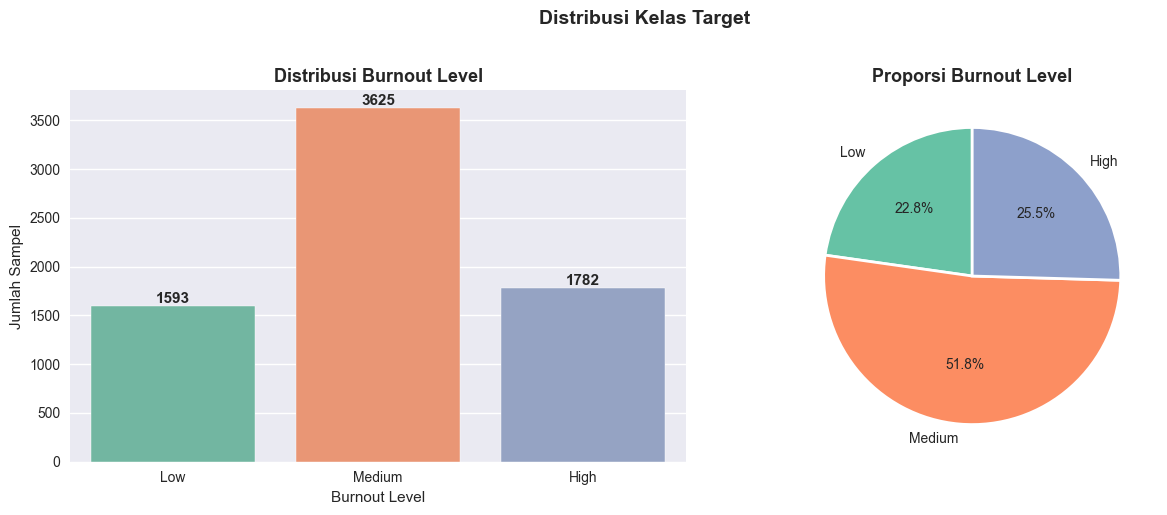

Distribusi kelas:
  Low     :  1593 (22.8%)
  Medium  :  3625 (51.8%)
  High    :  1782 (25.5%)


In [29]:
order = ['Low', 'Medium', 'High']
counts = df_clean['burnout_level'].value_counts()[order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count plot
sns.countplot(x='burnout_level', data=df_clean, order=order,
              ax=axes[0], palette='Set2', edgecolor='white')
axes[0].set_title('Distribusi Burnout Level', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Burnout Level')
axes[0].set_ylabel('Jumlah Sampel')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
colors = sns.color_palette('Set2', 3)
axes[1].pie(counts, labels=order, autopct='%1.1f%%', startangle=90,
            colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Burnout Level', fontsize=13, fontweight='bold')

plt.suptitle('Distribusi Kelas Target', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Distribusi kelas:")
for level in order:
    n = counts[level]
    print(f"  {level:8s}: {n:5d} ({n/len(df_clean)*100:.1f}%)")

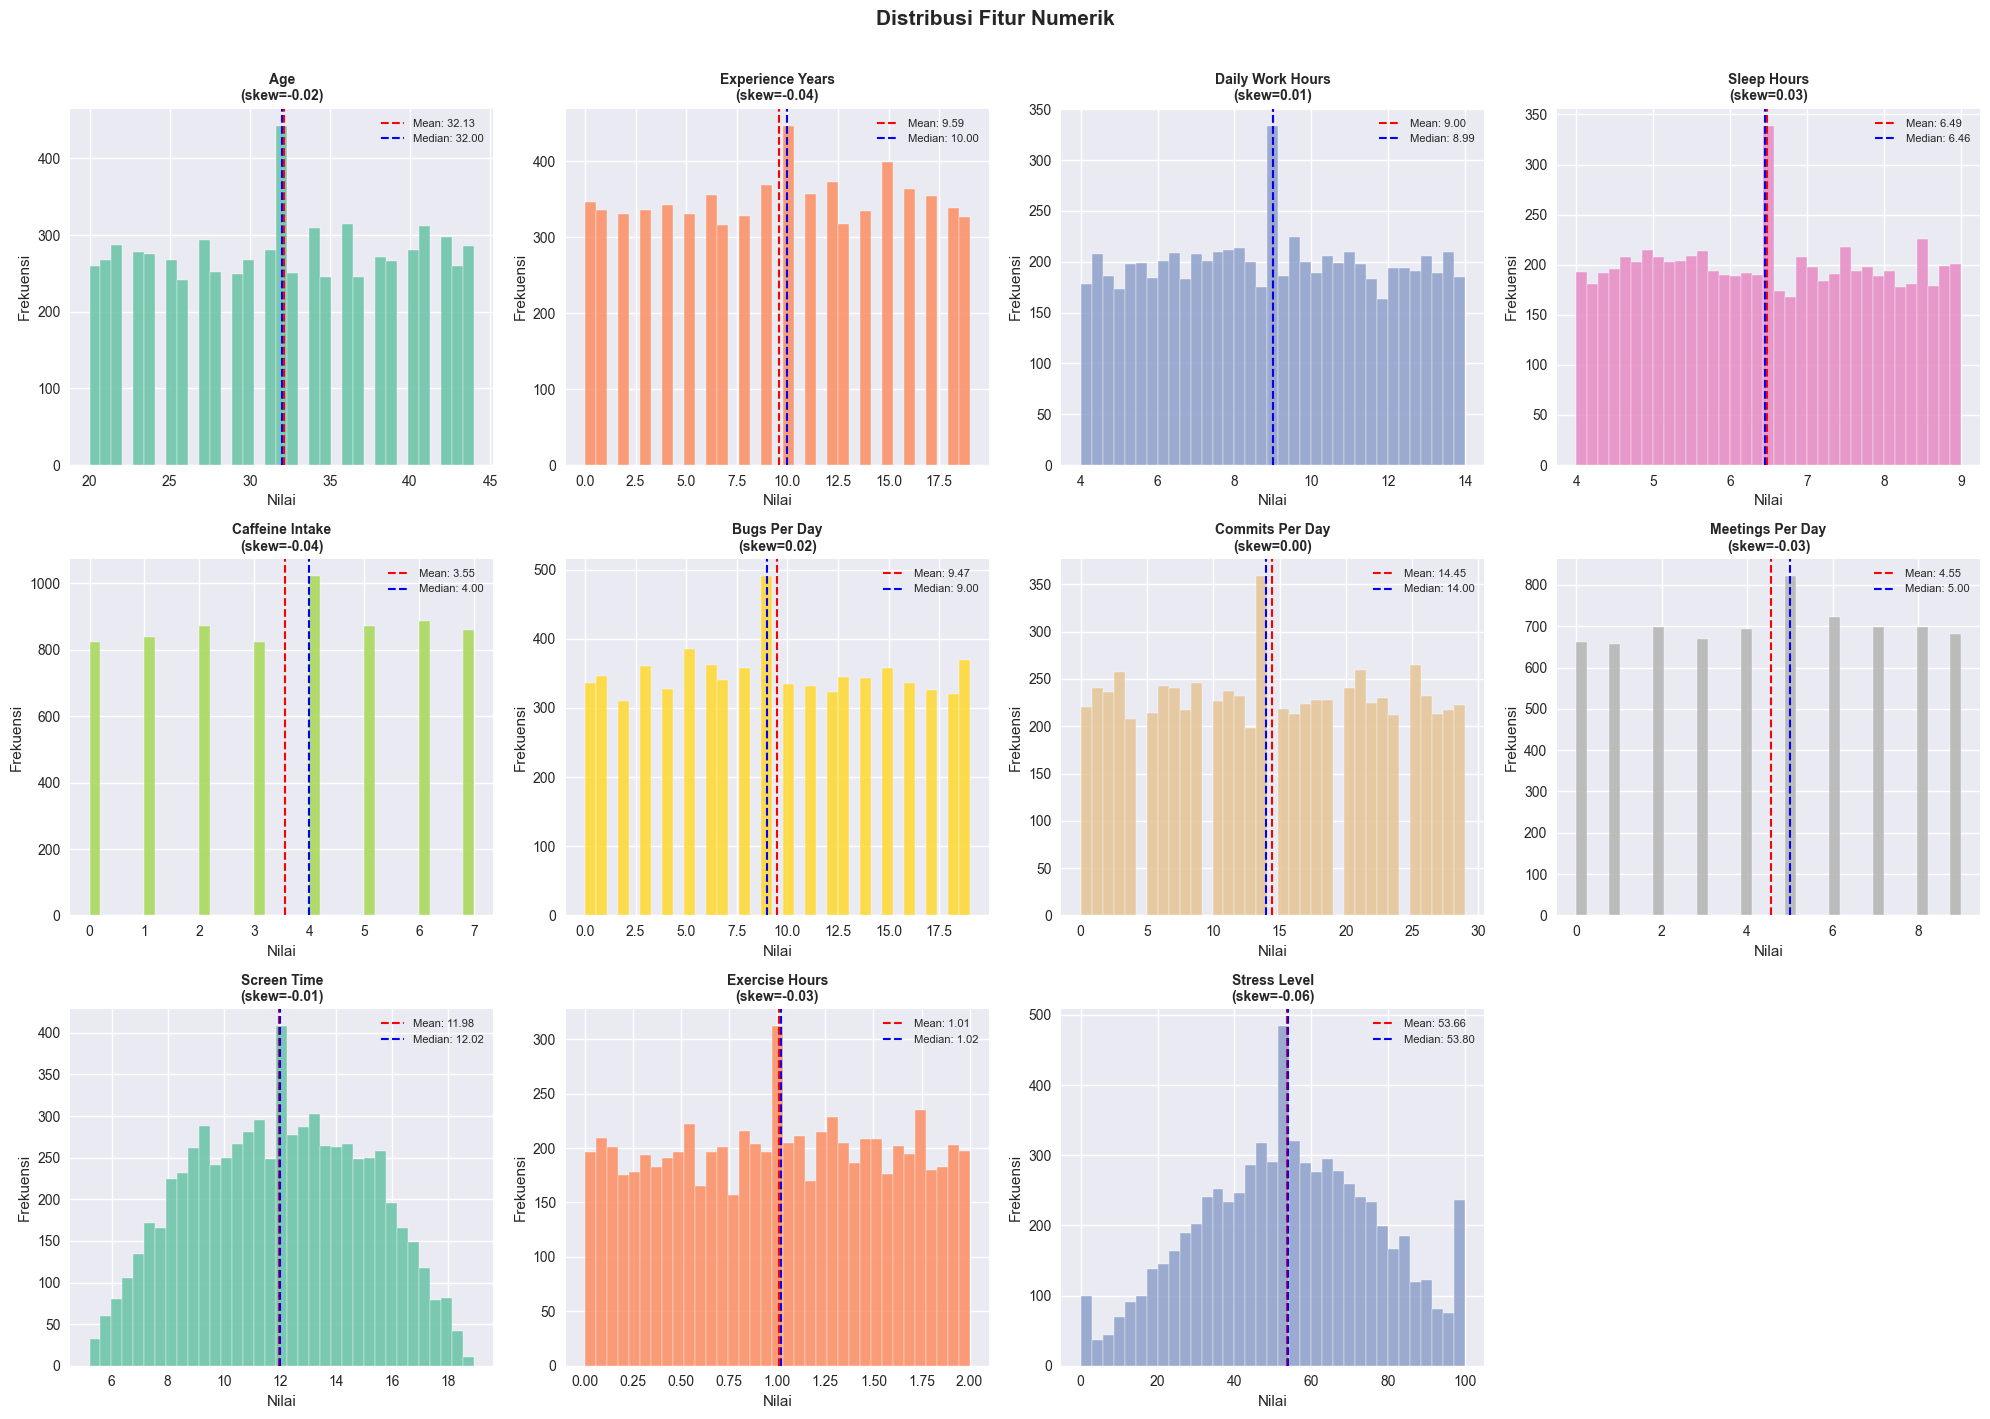

In [30]:
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
palette  = sns.color_palette('Set2', len(num_cols))

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col], bins=35, color=palette[i], edgecolor='white', alpha=0.85)
    axes[i].axvline(df_clean[col].mean(),   color='red',  linestyle='--', lw=1.5,
                    label=f'Mean: {df_clean[col].mean():.2f}')
    axes[i].axvline(df_clean[col].median(), color='blue', linestyle='--', lw=1.5,
                    label=f'Median: {df_clean[col].median():.2f}')
    skew = df_clean[col].skew()
    axes[i].set_title(f"{col.replace('_', ' ').title()}\n(skew={skew:.2f})",
                      fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
### Insight Distribusi Target

Pertanyaan kami ajukan adalah Apakah distribusi kelas burnout seimbang? Apakah ada class imbalance?

**Temuan:**
- Medium (51.8%), High (25.5%), Low (22.8%)

**Interpretasi:**

Distribusi ini tergolong cukup seimbang sehingga accuracy masih valid sebagai metrik, tapi kita tetap akan melihat F1-score per kelas saat modeling untuk memastikan model tidak mengabaikan kelas Low atau High.

## 11. Preprocessing: Encoding Target Variable

Algoritma ML bekerja dengan angka, bukan string. Kolom `burnout_level` perlu dikonversi ke format numerik.

Karena target memiliki urutan alami (Low < Medium < High), kita gunakan Ordinal Encoding:


In [33]:
ordinal_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_clean['burnout_encoded'] = df_clean['burnout_level'].map(ordinal_map)

## 9. Analisis Korelasi

mengukur hubungan linear antara dua variabel numerik, dengan nilai antara -1 hingga +1:
- **+1** = korelasi positif sempurna
- **-1** = korelasi negatif sempurna  
- **0** = tidak ada korelasi linear

Analisis korelasi berguna untuk:
1. Mengidentifikasi fitur yang paling relevan dengan target.
2. Mendeteksi multikolinearitas


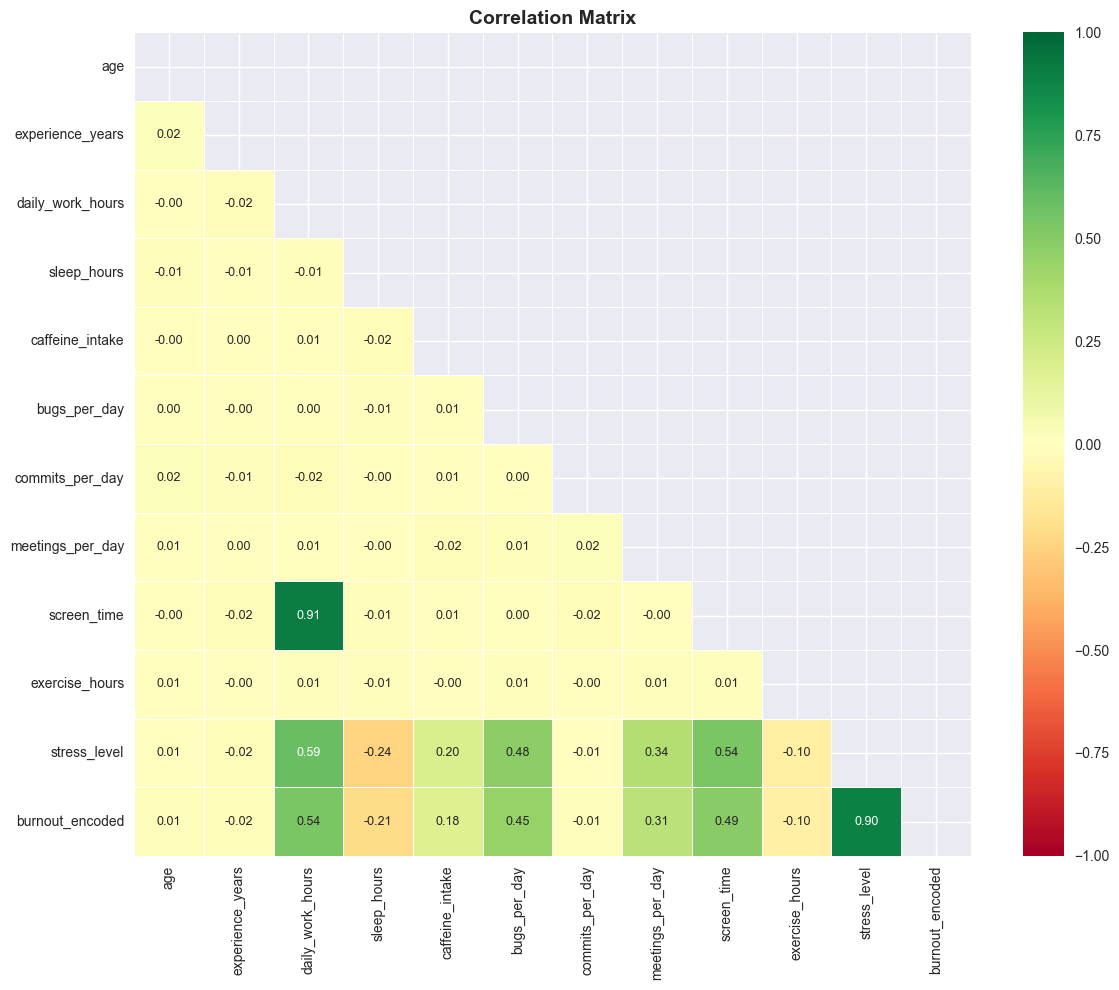

In [35]:
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
corr = df_clean[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
### Insight Korelasi

Pertanyaan yang kami ajukan: apakah ada fitur yang terlalu saling berkaitan? Dan fitur mana yang paling berkorelasi dengan target burnout?

**Temuan:**
- `stress_level`dan `burnout_encoded` = 0.90 memiliki korelasi tertinggi dengan target, jauh melampaui fitur lain
- `daily_work_hours` dan `screen_time` = 0.91 terjadi multikolinearitas antar fitur
- Sebagian besar korelasi antar fitur mendekati 0 sehingga fitur-fitur lain relatif independen satu sama lain

**Interpretasi:**

Multikolinearitas `daily_work_hours` dan `screen_time`:

Menurut kami dua fitur ini bercerita hal yang hampir sama dimana seorang developer yang kerja lama cenderung juga lama di depan layar. Untuk model berbasis koefisien seperti Logistic Regression, ini bisa membuat koefisien keduanya tidak stabil. Sehingga kami akan Drop `screen_time` ketika menggunakan model linear

Hubungan `stress_level` dengan targer:
- stress_level berkorelasi tinggi dengan target tapi menurut kami kurang relevan
- Tidak bisa diukur secara objektif di dunia nyata karena sangat subjektif
- Misalkan ada pertanyaan "Seberapa stress kamu?" menurut kami sama saja pertanyaannya dengan "Seberapa burnout kamu?"
- Model yang dibangun dengan `stress_level` tidak akan generalizable pada saat deployment


## 10. Analisis Bivariat (fitur dengan target)

Disini kami melakukan analisis bivariat dengan membandingkan distribusi tiap fitur di setiap kelas target. Dimana ini bisa menjawab:
- Fitur mana yang paling bisa membedakan kelas Low, Medium, High
- Apakah ada trend yang jelas antara nilai fitur dan tingkat burnout?

Visualisasi yang digunakan:
- Boxplot untuk melihat median, spread, dan outlier per kelas
- Violin plot untuk melihat distribusi penuh atau density per kelas
- Stacked bar untuk melihat proporsi burnout level per kelompok usia

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9588\2124124582.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='burnout_level', y=col, data=df_clean, order=order,
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9588\2124124582.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='burnout_level', y=col, data=df_clean, order=order,
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9588\2124124582.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='burnout_level', y=col, data=df_clean, order=order,
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9

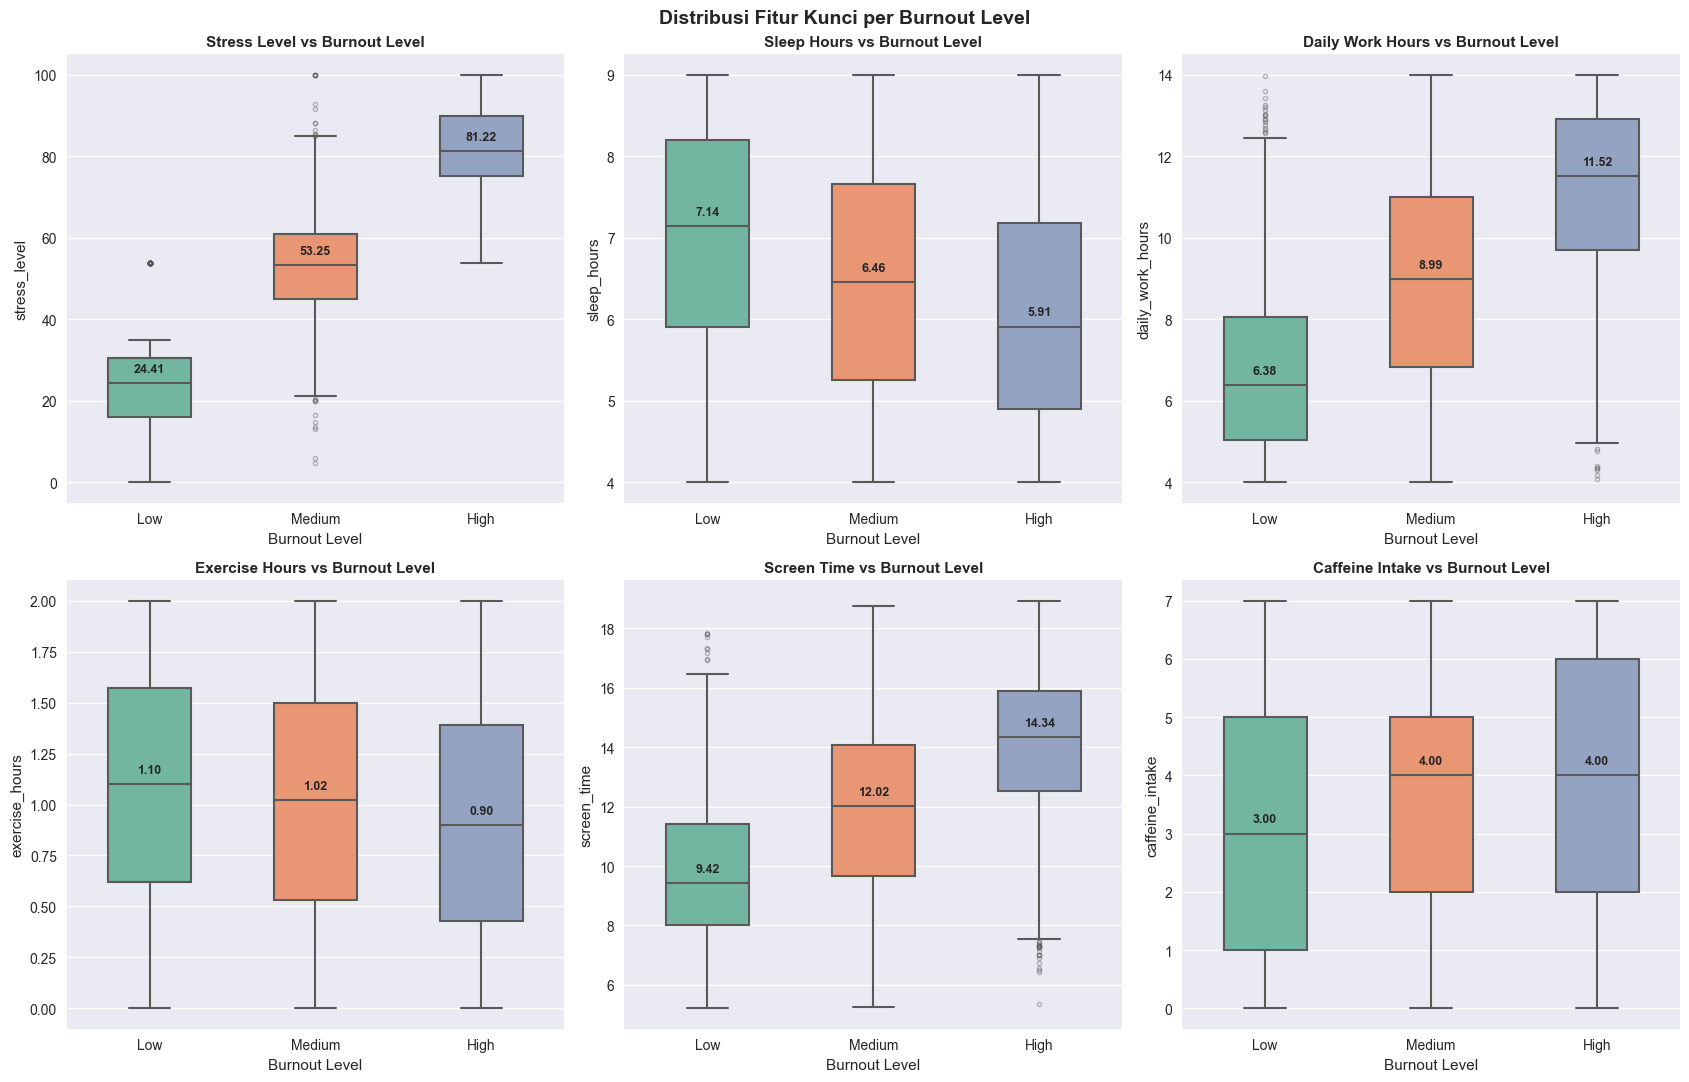

In [36]:
key_features = ['stress_level', 'sleep_hours', 'daily_work_hours',
                 'exercise_hours', 'screen_time', 'caffeine_intake']
order = ['Low', 'Medium', 'High']

fig, axes = plt.subplots(2, 3, figsize=(17, 11))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(x='burnout_level', y=col, data=df_clean, order=order,
                ax=axes[i], palette='Set2', width=0.5, linewidth=1.5,
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4})
    medians = df_clean.groupby('burnout_level')[col].median()[order]
    for j, (lvl, med) in enumerate(medians.items()):
        axes[i].text(j, med + (df_clean[col].max() - df_clean[col].min()) * 0.02,
                     f'{med:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[i].set_title(f"{col.replace('_', ' ').title()} vs Burnout Level",
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Burnout Level')
    axes[i].set_ylabel(col)

plt.suptitle('Distribusi Fitur Kunci per Burnout Level',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9588\153902455.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='burnout_level', y='stress_level', data=df_clean,


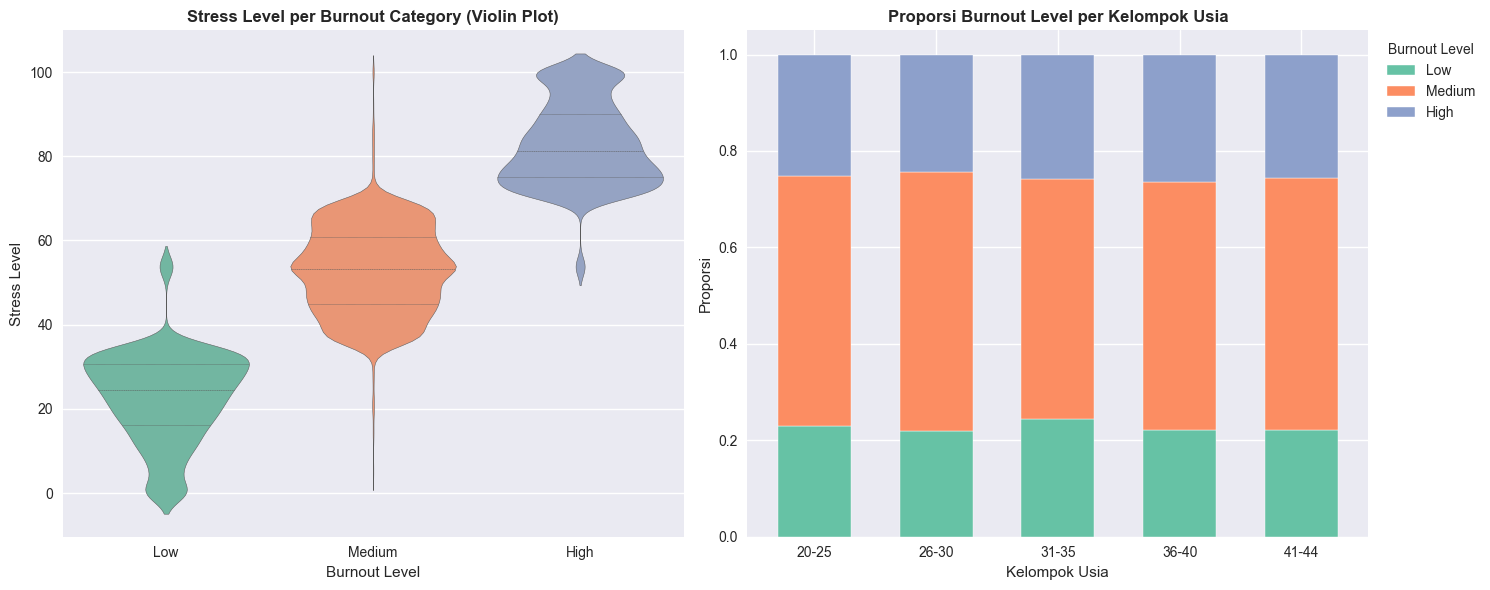

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.violinplot(x='burnout_level', y='stress_level', data=df_clean,
               order=order, palette='Set2', inner='quartile', ax=axes[0])
axes[0].set_title('Stress Level per Burnout Category (Violin Plot)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Burnout Level')
axes[0].set_ylabel('Stress Level')

df_clean['age_group'] = pd.cut(df_clean['age'], bins=[19, 25, 30, 35, 40, 45],
                                labels=['20-25', '26-30', '31-35', '36-40', '41-44'])
age_burnout = (df_clean.groupby(['age_group', 'burnout_level'], observed=True)
               .size().unstack(fill_value=0)[order])
age_burnout_pct = age_burnout.div(age_burnout.sum(axis=1), axis=0)
age_burnout_pct.plot(kind='bar', stacked=True, ax=axes[1],
                     color=sns.color_palette('Set2', 3), edgecolor='white', width=0.6)
axes[1].set_title('Proporsi Burnout Level per Kelompok Usia', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kelompok Usia')
axes[1].set_ylabel('Proporsi')
axes[1].legend(title='Burnout Level', bbox_to_anchor=(1.01, 1))
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

---
### Insight Analisis Bivariat

**Pertanyaan yang kami ajukan:** Fitur mana yang paling mampu membedakan antara karyawan burnout rendah, sedang, dan tinggi?

**Temuan (diurutkan dari paling diskriminatif):**

1. **`stress_level`**: pemisahan kelas paling jelas, Namun fitur ini akan **di-drop dari modeling** karena menurut kami kurang relevan (lihat penjelasan di section berikutnya).
2. **`sleep_hours`** menunjukan tren negatif: makin sedikit tidur maka burnout makin tinggi.
3. **`daily_work_hours`** menunjukan tren positif: jam kerja panjang maka burnout lebih tinggi.
4. **`screen_time`** menunjukan tren positif sama sepertin `daily_work_hours`. Keduanya kami coba pertahankan karena secara konsep mengukur hal berbeda jam kerja tinggi tidak otomatis berarti screen time tinggi (seseorang bisa kerja sedikit tapi lama main HP), begitu pun sebaliknya.
5. **`exercise_hours`** menunjukan tren negatif: olahraga lebih banyak cenderung melindungi dari burnout tinggi.
6. **`caffeine_intake`** ada perbedaan antar kelas kecil dimana ada kemungkinan bukan fitur yang signifikan.
7. **`age_group`**: proporsi burnout merata di semua kelompok usia sehingga menurut kami usia bukan faktor pembeda utama.

**Interpretasi:**

Pola ini konsisten dengan teori burnout: *jam kerja panjang + tidur kurang + jarang olahraga → burnout tinggi*.
Namun bisa saja karyawan yang sudah burnout justru jadi tidur lebih sedikit (bukan sebaliknya), atau keduanya disebabkan faktor ketiga yang sama.

## 11. Feature Selection

### Feature Selection Drop

Berdasarkan analisis korelasi dan bivariat, `stress_level` di-drop dari fitur karena tidak relevan:
- Tidak bisa diukur secara objektif di dunia nyata karena sangat subjektif
- Misalkan ada pertanyaan "Seberapa stress kamu?" menurut kami sama saja pertanyaannya dengan "Seberapa burnout kamu?"
- Model yang dibangun dengan `stress_level` tidak akan generalizable pada saat deployment

### Fitur Final untuk Modeling
`age`, `experience_years`, `daily_work_hours`, `screen_time`, `sleep_hours`, `exercise_hours` , `caffeine_intake`, `bugs_per_day`, `commits_per_day`, `meetings_per_day` 


In [38]:
df_final = df_clean.drop(columns=['age_group', 'burnout_level', 'stress_level'])
print(f"\nShape dataset final : {df_final.shape}")
print(f"Kolom fitur : {[c for c in df_final.columns if c != 'burnout_encoded']}")

df_final.to_csv('dataset_preprocessed.csv', index=False)
df_final.head()


Shape dataset final : (7000, 11)
Kolom fitur : ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours']


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,burnout_encoded
0,26.00,12.00,10.33,4.45,2.00,11.00,4.00,1.00,15.07,0.14,1
1,39.00,10.00,8.62,5.77,5.00,15.00,11.00,5.00,13.25,0.54,2
2,34.00,13.00,8.99,4.03,5.00,2.00,18.00,9.00,11.18,1.54,1
3,30.00,1.00,6.85,6.47,2.00,15.00,26.00,1.00,11.14,0.96,1
4,27.00,7.00,4.24,5.80,4.00,9.00,17.00,7.00,8.05,0.36,0


## 12. Ringkasan & Insight EDA

### Preprocessing
| Langkah | Keputusan |
|---------|-----------|
| Missing values | 1510 baris (21.57%) menggunakan Median imputation (numerik), mode (`burnout_level`) |
| Duplikat | Tidak ditemukan |
| Outlier | Tidak ditemukan |
| Drop `stress_level` | tidak bisa diukur objektif di dunia nyata |
| Encoding target | Ordinal Encoding: Low=0, Medium=1, High=2 |

### Key Findings dari EDA

1. **Distribusi kelas seimbang**
Medium (51.8%), High (25.5%), Low (22.8%). Accuracy valid sebagai metrik, F1-score per kelas tetap dipantau saat modeling.

2. **`stress_level` paling diskriminatif tapi di-drop** 
korelasi 0.90 dengan target dan tidak bisa diukur objektif

3. **`daily_work_hours` dan `screen_time`**
secara konsep mengukur hal berbeda; korelasi tinggi adalah artefak dataset synthetic. Untuk model linear, pertimbangkan drop `screen_time`.

4. **`sleep_hours` berkorelasi negatif dengan burnout** 
tidur cukup bersifat protektif terhadap burnout.

5. **`exercise_hours` juga protektif** 
olahraga lebih banyak cenderung menurunkan burnout.

6. **Tidak ada multikolinearitas parah antar fitur lain**
sebagian besar korelasi antar fitur mendekati 0, semua fitur membawa informasi yang relatif independen.


### Fitur Final (10 fitur + 1 target)
`age`, `experience_years`, `daily_work_hours`, `sleep_hours`, `caffeine_intake`, `bugs_per_day`, `commits_per_day`, `meetings_per_day`, `screen_time`, `exercise_hours` dan **target:** `burnout_encoded`